# matlab

# 6. projekt

Adott egy kezdeti érték feladat:

\begin{gather*}
y' = f(t, y)\\
y(a)=b
\end{gather*}


Írjon egy matlab függvényt (`succ_approx`) melynek paraméterei rendre:
az `y, t, f` szimbolikus kifejezések, az `a, b` számok és egy `n` pozitív egész:

```octave
function yn = succ_approx(y,t,f,a,b,n)
  % your code comes here
end
```

Az `yn` visszatérési érték az a szimbolikus függvény legyen melyet úgy kapunk, hogy `n` lépést végzünk a fokozatos közelítés módszerével az `y0=b` konstans függvényből kiindulva.

A többi projektnél felhasznált ismeretek (bőven) elegendőek a függvény definiálásához, ami ha 
5-6 sornál hosszabb, akkor valamit elbonyolítottunk.



## példa 1

\begin{gather*}
y'=y\\
y(0)=1
\end{gather*}
Tudjuk, hogy az egyértelmű megoldás: $y(t)=e^{t}$. Lássuk mit kapunk a fokozatos közelítés módszerével:

 
theo =
 
exp(t)
 
 
approx1(t) =
 
t + 1
 
 
approx2(t) =
 
(t*(t + 2))/2 + 1
 
 
approx4(t) =
 
t^4/24 + t^3/6 + t^2/2 + t + 1
 
 
approx8(t) =
 
t^8/40320 + t^7/5040 + t^6/720 + t^5/120 + t^4/24 + t^3/6 + t^2/2 + t + 1
 


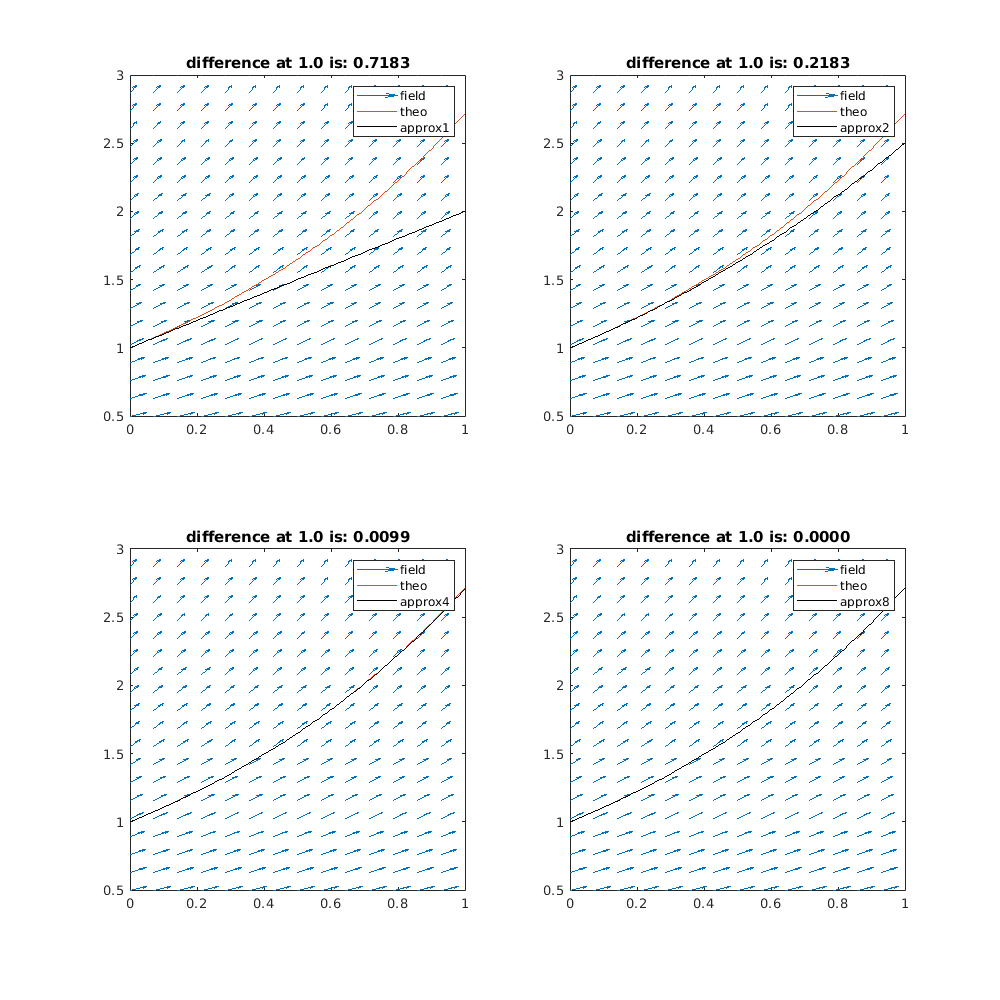

In [105]:
%plot -s 1000,1000
syms y(t) 
eq(t) = diff(y) == y;
theo = dsolve(eq, y(0)==1)
numtheo = matlabFunction(theo);
t0 = 0;
tend = 1;
TT = linspace(t0, tend);

rhs = @(t,y) y;
[T,Y] = meshgrid(linspace(t0,tend,15), linspace(0.5,3,20));
dT = ones(size(T));
dY = rhs(T, Y);
L = sqrt(dT.^2 + dY.^2);
dT = dT ./ L;
dY = dY ./ L;


% this is the way of calling your fun:
syms yy;
f(t, yy) = yy;
approx1 = succ_approx(y, t, f, 0, 1, 1)
approx2 = succ_approx(y, t, f, 0, 1, 2)
approx4 = succ_approx(y, t, f, 0, 1, 4)
approx8 = succ_approx(y, t, f, 0, 1, 8)

num1 = matlabFunction(approx1);
num2 = matlabFunction(approx2);
num4 = matlabFunction(approx4);
num8 = matlabFunction(approx8);

subplot(2,2,1);
quiver(T, Y, dT, dY, 0.4)
hold on;
plot(TT, numtheo(TT))
plot(TT, num1(TT),'k')
legend("field","theo", "approx1")
d = abs(numtheo(tend)-num1(tend));
title(sprintf("difference at %.1f is: %.4f",tend,d));
axis([t0,tend,0.5,3])

subplot(2,2,2);
quiver(T, Y, dT, dY, 0.4)
hold on;
plot(TT, numtheo(TT))
plot(TT, num2(TT),'k')
legend("field","theo", "approx2")
d = abs(numtheo(tend)-num2(tend));
title(sprintf("difference at %.1f is: %.4f",tend,d));
axis([t0,tend,0.5,3])


subplot(2,2,3);
quiver(T, Y, dT, dY, 0.4)
hold on;
plot(TT, numtheo(TT))
plot(TT, num4(TT),'k')
legend("field","theo", "approx4")
d = abs(numtheo(tend)-num4(tend));
title(sprintf("difference at %.1f is: %.4f",tend,d));
axis([t0,tend,0.5,3])


subplot(2,2,4);
quiver(T, Y, dT, dY, 0.4)
hold on;
plot(TT, numtheo(TT))
plot(TT, num8(TT),'k')
legend("field","theo", "approx8")
d = abs(numtheo(tend)-num8(tend));
title(sprintf("difference at %.1f is: %.4f",tend,d));
axis([t0,tend,0.5,3])






## példa 2

\begin{gather*}
y'=sin(t)-y\\
y(0)=1
\end{gather*}

 
theo =
 
(3*exp(-t))/2 - (2^(1/2)*cos(t + pi/4))/2
 
 
approx1(t) =
 
2 - cos(t) - t
 
 
approx2(t) =
 
t^2/2 - 2^(1/2)*cos(t + pi/4) - 2*t + 2
 
 
approx4(t) =
 
t^4/24 - t^3/3 + t^2 - t + 1
 
 
approx8(t) =
 
t^8/40320 - t^7/2520 + t^6/360 - t^5/120 + t^4/24 - t^3/3 + t^2 - t + 1
 


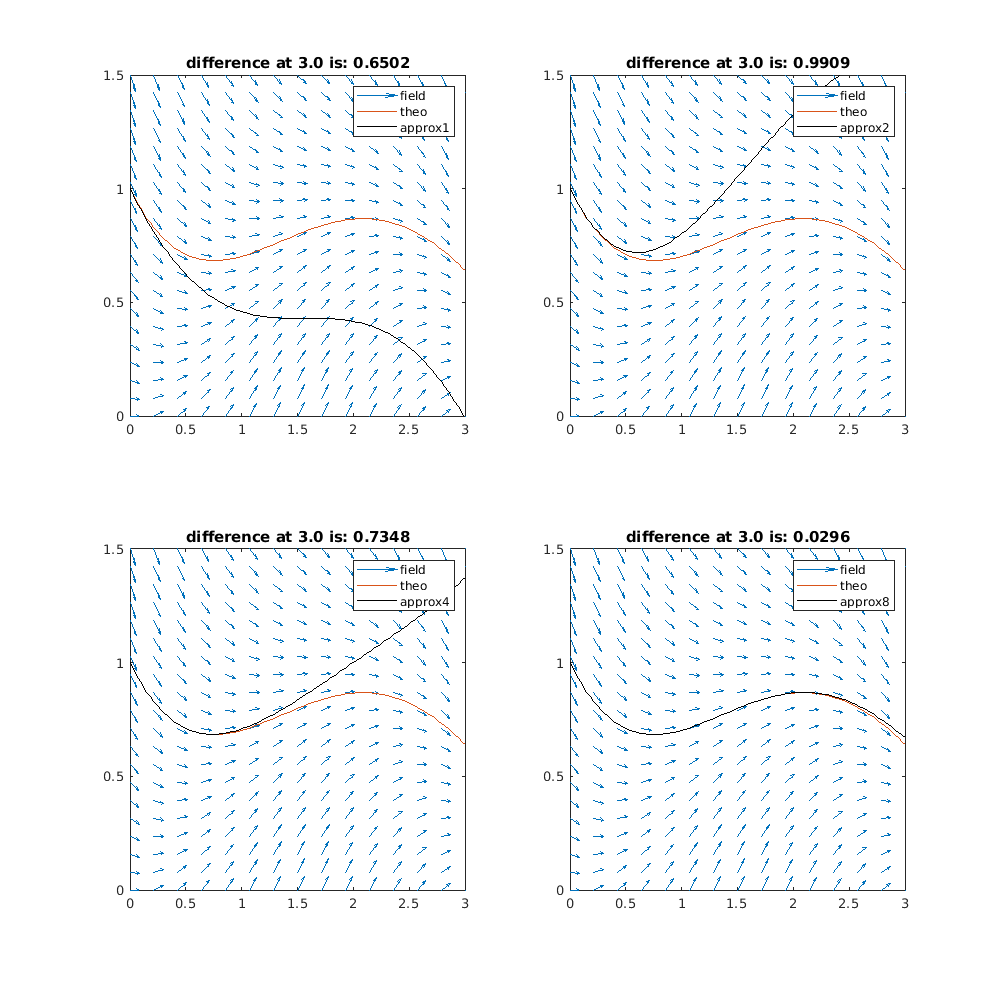

In [104]:
%plot -s 1000,1000
syms y(t) 
eq(t) = diff(y) == sin(t)-y;
theo = dsolve(eq, y(0)==1)
numtheo = matlabFunction(theo);
t0 = 0;
tend = 3;
TT = linspace(t0, tend);

rhs = @(t,y) sin(t)-y;
[T,Y] = meshgrid(linspace(t0,tend,15), linspace(0,1.5,20));
dT = ones(size(T));
dY = rhs(T, Y);
L = sqrt(dT.^2 + dY.^2);
dT = dT ./ L;
dY = dY ./ L;


% this is the way of calling your fun:
syms yy;
f(t, yy) = sin(t)-yy;
approx1 = succ_approx(y, t, f, t0, 1, 1)
approx2 = succ_approx(y, t, f, t0, 1, 2)
approx4 = succ_approx(y, t, f, t0, 1, 4)
approx8 = succ_approx(y, t, f, t0, 1, 8)

num1 = matlabFunction(approx1);
num2 = matlabFunction(approx2);
num4 = matlabFunction(approx4);
num8 = matlabFunction(approx8);

subplot(2,2,1);
quiver(T, Y, dT, dY, 0.4)
hold on;
plot(TT, numtheo(TT))
plot(TT, num1(TT),'k')
legend("field","theo", "approx1")
d = abs(numtheo(tend)-num1(tend));
title(sprintf("difference at %.1f is: %.4f",tend,d));
axis([t0,tend,0,1.5])

subplot(2,2,2);
quiver(T, Y, dT, dY, 0.4)
hold on;
plot(TT, numtheo(TT))
plot(TT, num2(TT),'k')
legend("field","theo", "approx2")
d = abs(numtheo(tend)-num2(tend));
title(sprintf("difference at %.1f is: %.4f",tend,d));
axis([t0,tend,0,1.5])


subplot(2,2,3);
quiver(T, Y, dT, dY, 0.4)
hold on;
plot(TT, numtheo(TT))
plot(TT, num4(TT),'k')
legend("field","theo", "approx4")
d = abs(numtheo(tend)-num4(tend));
title(sprintf("difference at %.1f is: %.4f",tend,d));
axis([t0,tend,0,1.5])


subplot(2,2,4);
quiver(T, Y, dT, dY, 0.4)
hold on;
plot(TT, numtheo(TT))
plot(TT, num8(TT),'k')
legend("field","theo", "approx8")
d = abs(numtheo(tend)-num8(tend));
title(sprintf("difference at %.1f is: %.4f",tend,d));
axis([t0,tend,0,1.5])




